# Definindo Parametros

## Modelo: LightGBM

O objetivo desse notebook é analisar o funcionamento do modelo de classificação LightGBM para definir o gênero de uma música com base nas suas audio features. 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Leitura dos Dados

In [3]:
caminho_arquivo = '../data/spotify_songs.csv'

df = pd.read_csv(caminho_arquivo)

features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'explicit']


## Limpeza do dataset: removendo duplicatas

Percebemos ao abrir o dataset em uma planilha que havia muitas músicas repetidas com IDs diferentes, pois o Spotify indica um ID distindo para músicas iguais que são republicadas em albuns diferentes, por exemplo. Tendo em vista isso fizemos uma limpeza nessas duplicatas.

In [4]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.copy()

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [5]:
# Selecionamos as colunas das audio features que importam
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicando a clusterização: K-Means

Resolvemos aplicar o modelo não supervisionado K-means para organizar nossas músicas em grupos com base nas suas audio features, uma vez que se considerássemos apenas a coluna `track_genre` para fazermos nossa classificação o modelo teria que lidar com 114 classes e apresentaria baixos valores de f1-score e acurácia.

In [6]:
print("Treinando o K-Means...")
kmeans = KMeans(n_clusters=15, random_state=42, n_init='auto')
df['macrovibe'] = kmeans.fit_predict(X_scaled)

print("Clusterização concluída! Nova coluna 'macrovibe' criada.")

Treinando o K-Means...
Clusterização concluída! Nova coluna 'macrovibe' criada.


## Modelo LightGBM

Nossa abordagem de classificação seguirá em duas etapas.

- Etapa 1:

Treinaremos um modelo para conseguir identificar a que cluster uma determinada música pertence

- Etapa 2:

Sabendo o cluster que a música pertence, aplicaremos um modelo especialista dentro do subset do cluster para definir o gênero real associado a música.

Abaixo está a elaboração do modelo LightGBM Roteador, que será o responsável pela classificação mais geral (clusters)

In [7]:
# Separando em Treino e Teste (80% para treinar, 20% para testar)
X_train, X_test, y_train, y_test = train_test_split(
    X, df['macrovibe'], test_size=0.2, random_state=42
)

# Instanciando e Treinando o LightGBM
print("Iniciando o treinamento do LightGBM")
roteador = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,    # Número de árvores
    learning_rate=0.1,   # Velocidade de aprendizado
    n_jobs=-1            # Usa todos os núcleos do seu processador
)

roteador.fit(X_train, y_train)

# 3. Fazendo previsões na base de teste
y_pred = roteador.predict(X_test)

# 4. Imprimindo a Acurácia Geral
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Iniciando o treinamento do LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2039
[LightGBM] [Info] Number of data points in the train set: 65075, number of used features: 9
[LightGBM] [Info] Start training from score -3.305503
[LightGBM] [Info] Start training from score -3.247321
[LightGBM] [Info] Start training from score -2.124627
[LightGBM] [Info] Start training from score -2.517884
[LightGBM] [Info] Start training from score -3.499031
[LightGBM] [Info] Start training from score -1.920676
[LightGBM] [Info] Start training from score -2.477725
[LightGBM] [Info] Start training from score -4.545156
[LightGBM] [Info] Start training from score -3.057452
[LightGBM] [Info] Start training from score -2.391645
[LightGBM] [Info] Start training from score -3.167218
[LightGBM] [Info] 

Como já definimos nosso modelo geral, precisamos treinar nossos modelos especialistas para cada cluster (vibe)

In [8]:
# Criamos um dicionário vazio para guardar nossos modelos
especialistas = {}

todas_as_vibes = df['macrovibe'].unique()

print("Treinando os Especialistas (com Filtro de Ruído)...\n")

# Variável de controle: Um gênero precisa ter pelo menos 15 músicas 
# dentro de um cluster para ser levado a sério pelo especialista
MIN_MUSICAS_POR_GENERO = 15

for vibe in todas_as_vibes:
    df_vibe = df[df['macrovibe'] == vibe]
    
    # Realizamos um  filtro dentro do cluster para garantir que os gêneros dentro dele
    # sejam possuam presença considerável, e não uma ou outra música perdida
    contagem = df_vibe['track_genre'].value_counts()
    generos_fortes = contagem[contagem >= MIN_MUSICAS_POR_GENERO].index
    df_vibe_limpo = df_vibe[df_vibe['track_genre'].isin(generos_fortes)]

    if len(df_vibe_limpo['track_genre'].unique()) <= 1:
        genero_unico = contagem.index[0] 
        especialistas[vibe] = genero_unico
        print(f"[{vibe}] - Ruído muito alto. Ficará fixo no gênero principal: '{genero_unico}'.")
        continue

    # Definimos X e y usando o dataframe limpo
    X_especialista = df_vibe_limpo[features]
    y_especialista = df_vibe_limpo['track_genre']
    
    # 3. Treinar o mini-modelo especialista
    modelo_especialista = lgb.LGBMClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1, verbose=-1)
    modelo_especialista.fit(X_especialista, y_especialista)
    
    # 4. Salva o modelo treinado
    especialistas[vibe] = modelo_especialista
    print(f"[{vibe}] - Especialista treinado! Gêneros reduzidos para: {len(y_especialista.unique())} (Eram {len(contagem)}).")

print("\nTodos os 15 especialistas estão prontos e blindados contra ruído!")


Treinando os Especialistas (com Filtro de Ruído)...

[5] - Especialista treinado! Gêneros reduzidos para: 94 (Eram 111).
[6] - Especialista treinado! Gêneros reduzidos para: 65 (Eram 93).
[3] - Especialista treinado! Gêneros reduzidos para: 90 (Eram 111).
[14] - Especialista treinado! Gêneros reduzidos para: 78 (Eram 106).
[9] - Especialista treinado! Gêneros reduzidos para: 96 (Eram 111).
[2] - Especialista treinado! Gêneros reduzidos para: 78 (Eram 110).
[11] - Especialista treinado! Gêneros reduzidos para: 79 (Eram 112).
[13] - Especialista treinado! Gêneros reduzidos para: 47 (Eram 97).
[1] - Especialista treinado! Gêneros reduzidos para: 34 (Eram 78).
[8] - Especialista treinado! Gêneros reduzidos para: 19 (Eram 41).
[4] - Especialista treinado! Gêneros reduzidos para: 35 (Eram 88).
[12] - Especialista treinado! Gêneros reduzidos para: 37 (Eram 93).
[0] - Especialista treinado! Gêneros reduzidos para: 53 (Eram 102).
[10] - Especialista treinado! Gêneros reduzidos para: 33 (Eram 79

A função `classificar_musica_hierarquicamente` será a responsável por receber as audio features de uma música como entrada e cuspir tanto o cluster quanto o gênero da música

In [9]:
def classificar_musica_hierarquicamente(audio_features_nova_musica):
    """
    Recebe um DataFrame de 1 linha contendo as features numéricas da música.
    Exemplo: audio_features_nova_musica = X_test.iloc[[0]]
    """
    vibe_predita = roteador.predict(audio_features_nova_musica)[0]
    
    especialista = especialistas[vibe_predita]
    
    # Se o especialista for só uma string (caso de gênero único visto acima)
    if isinstance(especialista, str):
        genero_predito = especialista
    else:
        # Pede para o mini-modelo decidir qual é o gênero final
        genero_predito = especialista.predict(audio_features_nova_musica)[0]
        
    return vibe_predita, genero_predito

In [23]:
# ==== TESTANDO A NOSSA CASCATA COM UMA MÚSICA ALEATÓRIA ====

# Sorteia 1 índice (linha) aleatório APENAS DA BASE DE TESTE (Dados Inéditos)
indice_sorteado = X_test.sample(n=1).index[0]

# Extrai as informações usando esse índice
musica_sorteada_features = X_test.loc[[indice_sorteado]]
vibe_real = y_test.loc[indice_sorteado]
genero_real = df.loc[indice_sorteado, 'track_genre']
nome_musica = df.loc[indice_sorteado, 'track_name']
artista_musica = df.loc[indice_sorteado, 'artists']

vibe_predita, genero_predito = classificar_musica_hierarquicamente(musica_sorteada_features)

print("="*60)
print(f"MÚSICA SORTEADA: {nome_musica} - {artista_musica}")
print("="*60)
print("GABARITO REAL (O QUE ELA REALMENTE É):")
print(f"  - Macrovibe Original: {vibe_real}")
print(f"  - Gênero Original:    {genero_real}")
print("-" * 60)
print("PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:")
print(f"  - Fase 1 (Roteador) previu a Vibe:  -> '{vibe_predita}'")
print(f"  - Fase 2 (Especialista) previu o Gênero: -> '{genero_predito}'")
print("="*60)

# Verificação de acerto visual
if genero_real == genero_predito:
    print("✅ RESULTADO: O modelo ACERTOU NA MOSCA!")
elif vibe_real == vibe_predita:
    print("⚠️ RESULTADO: Acertou a Macrovibe, mas confundiu o subgênero.")
else:
    print("❌ RESULTADO: O modelo errou a previsão.")

MÚSICA SORTEADA: Fragment, Pt. 1 - Daigo Hanada
GABARITO REAL (O QUE ELA REALMENTE É):
  - Macrovibe Original: 8
  - Gênero Original:    piano
------------------------------------------------------------
PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:
  - Fase 1 (Roteador) previu a Vibe:  -> '8'
  - Fase 2 (Especialista) previu o Gênero: -> 'piano'
✅ RESULTADO: O modelo ACERTOU NA MOSCA!


## Visualizando matriz de confusão e gráfico de importância de features

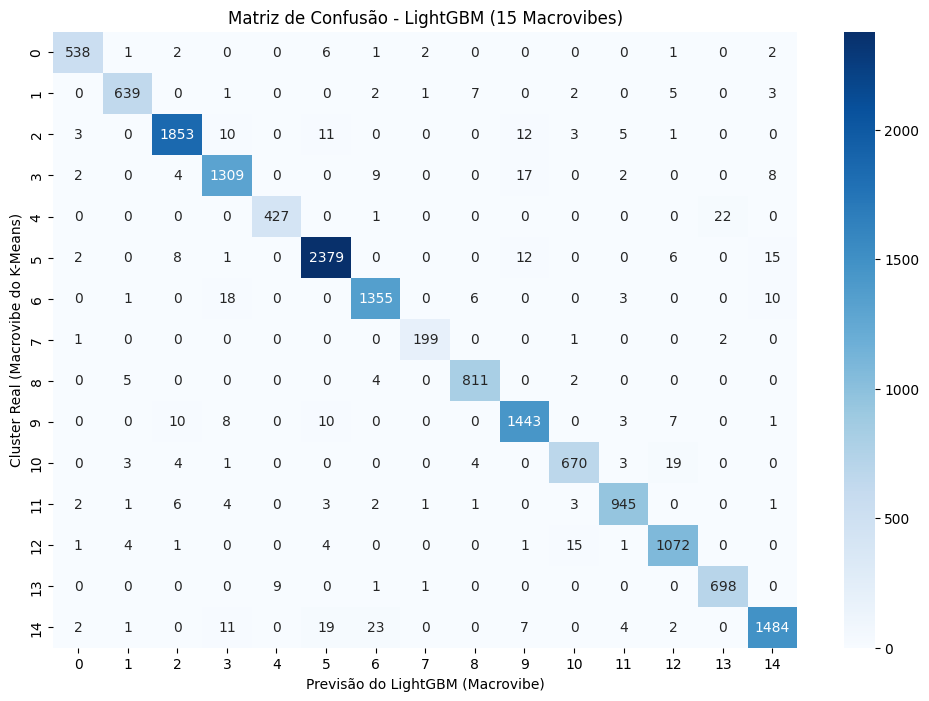

<Figure size 1000x600 with 0 Axes>

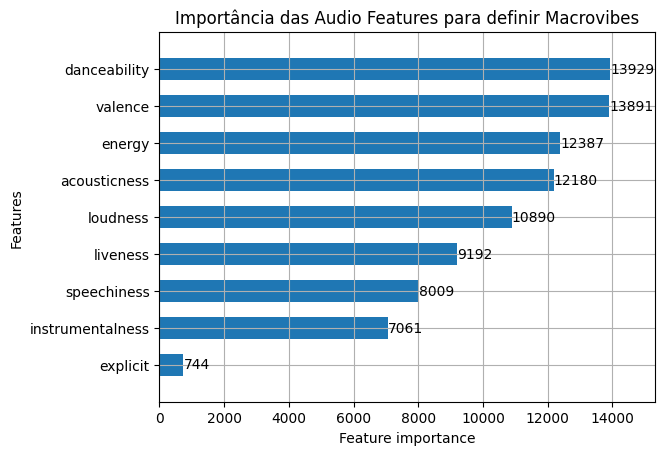

In [20]:
# Matriz de confusão
plt.figure(figsize=(12, 8))
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do LightGBM (Macrovibe)')
plt.ylabel('Cluster Real (Macrovibe do K-Means)')
plt.title('Matriz de Confusão - LightGBM (15 Macrovibes)')
plt.show()

# Importância das features
plt.figure(figsize=(10, 6))

lgb.plot_importance(roteador, max_num_features=10, height=0.6, 
                    title='Importância das Audio Features para definir Macrovibes')
plt.show()

## Observando os centroides dos clusters 

In [12]:
# # 1. Extraindo os centroides na escala original dos dados
# centroides_originais = scaler.inverse_transform(kmeans.cluster_centers_)

# # 2. Convertendo em um DataFrame do Pandas para facilitar a leitura
# df_centroides = pd.DataFrame(centroides_originais, columns=features)
# df_centroides.index.name = 'Cluster'

# # 3. Exibindo a tabela formatada com duas casas decimais
# print("Média das Audio Features por Cluster (Centroides Reais):")
# display(df_centroides.round(2))


# plt.figure(figsize=(14, 8))
# # Usamos dados normalizados apenas para o visual do mapa de calor ficar na mesma escala cromática
# df_centroides_normalizados = pd.DataFrame(kmeans.cluster_centers_, columns=features)
# sns.heatmap(df_centroides_normalizados, annot=df_centroides.values.round(2), fmt=".2f", cmap="RdYlBu")
# plt.title("Perfil dos Centroides por Cluster (Valores Reais anotados)")
# plt.ylabel("ID do Cluster")
# plt.xlabel("Audio Features")
# plt.show()

In [13]:
# # 1. Definindo o dicionário de mapeamento completo (15 Clusters: de 0 a 14)
# mapeamento_vibes = {
#     0: "Rock / Metal / Alta Voltagem",
#     1: "Pop / Rádio Padrão A",
#     2: "Hip-Hop / Rap / Urbano",
#     3: "Acústico / Triste (Indie/Folk)",
#     4: "Pop Festa / Alto Astral",
#     5: "Eletrônica / EDM Instrumental",
#     6: "Pop / Rádio Padrão B",
#     7: "Ao Vivo / Shows",
#     8: "Clássica / Som Ambiente",
#     9: "Áudio Falado / Podcasts",
#     10: "Pop-Rock / Indie Pop Leve",
#     11: "Pop Dançante Contemporâneo",
#     12: "Pop Energético / Upbeat",
#     13: "Lo-Fi / Trilha Sonora Ambiente",
#     14: "Pop Acústico / Soft Pop"
# }

# # 2. Criando a nova coluna de Target (Gabarito) com os nomes legíveis
# df['macrovibe_nome'] = df['macrovibe'].map(mapeamento_vibes)

# # 3. Verificando se o mapeamento deu certo em uma amostra aleatória
# print("Amostra do dataset com as 15 Macrovibes mapeadas:")
# display(df[['track_name', 'artists', 'macrovibe', 'macrovibe_nome']].sample(5))

## Salvando nosso modelo treinado

In [19]:
# 1. Garantir que a pasta existe (opcional, mas evita erros)
os.makedirs("../backend/models", exist_ok=True)

# 2. Salvar o Modelo Roteador (A Fase 1)
caminho_roteador = "../backend/models/lightgbm_roteador.pkl"
joblib.dump(roteador, caminho_roteador)
print(f"Roteador salvo em: {caminho_roteador}")

# 3. Salvar os Modelos Especialistas (A Fase 2)
for cluster_id, modelo_especialista in especialistas.items():
    caminho_especialista = f"../backend/models/lightgbm_especialista_cluster_{cluster_id}.pkl"
    
    # Salva cada modelo com o nome do seu respectivo cluster
    joblib.dump(modelo_especialista, caminho_especialista)

print(f"Todos os {len(especialistas)} especialistas foram salvos com sucesso!")

Roteador salvo em: ../backend/models/lightgbm_roteador.pkl
Todos os 15 especialistas foram salvos com sucesso!
